# GARCH Volatility Forecasting and Volatility Targeting for Bitcoin and Ether

**Question:** Crypto volatility is not constant — calm months alternate with violent ones, and the violent ones cluster together. If tomorrow's volatility can be forecast from today's, an investor can hold *less* when risk is high and *more* when it is low, keeping the portfolio's risk roughly constant. Moreira & Muir (2017) found this "volatility targeting" raised Sharpe ratios for equity factors; Harvey et al. (2018) found it mainly trims the left tail; Cederburg et al. (2020) found the Sharpe gains do not hold up out-of-sample across most strategies. Does it work for Bitcoin and Ether, and which volatility forecast should drive it?

This notebook:
1. Downloads daily Binance prices for BTC and ETH since 2018 with `src/data.py`.
2. Shows the two facts that make volatility forecastable: volatility clustering and fat tails.
3. Fits a GARCH(1,1) model with Student-t errors by maximum likelihood, written from scratch with `scipy`.
4. Compares out-of-sample one-day-ahead forecasts from GARCH, RiskMetrics EWMA, a 30-day rolling window and a constant, using the MSE and QLIKE losses of Patton (2011).
5. Uses each forecast to run a volatility-targeted strategy, with no look-ahead and with trading costs, and compares it with buy-and-hold and with a static portfolio that holds the same average exposure.

*Inspired by WQU MScFE 560, Module 2 (Return & Volatility): measuring volatility, and why it changes over time.*

In [1]:
import subprocess
import sys
import warnings
from pathlib import Path

warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.optimize import minimize
from scipy.special import gammaln
from scipy import stats

plt.rcParams.update({"figure.figsize": (10, 4.5), "axes.grid": True, "grid.alpha": 0.3})
ANN = 365        # crypto trades every day of the year
TARGET = 0.50    # annualized volatility target for Section 5
COST = 0.0010    # trading cost: 10 bp per unit of weight traded

## 1. Data

Binance listed BTC/USDT and ETH/USDT in 2017; we start on 2018-01-01 so the sample includes the 2018 bear market, the March 2020 crash, the 2021 bull run, the 2022 collapse (LUNA, FTX) and the 2024–2026 cycle. The download uses a fixed date range so every run sees the same data; if it fails, the cell falls back to the CSVs in `src/data/` and prints the range it actually got.

In [2]:
# src/ sits next to the topic folders: one level up in the repo, two levels up locally (W*/<Topic>/)
SRC = next(p / "src" for p in Path.cwd().resolve().parents if (p / "src" / "data.py").exists())
SYMBOLS = ["BTC/USDT", "ETH/USDT"]
START, END = "2018-01-01", "2026-10-01"

cmd = [sys.executable, str(SRC / "data.py"), *SYMBOLS, "--since", START, "--until", END, "--full"]
result = subprocess.run(cmd, capture_output=True, text=True)
print("Downloaded from Binance" if result.returncode == 0 else "Download failed, using existing CSVs in src/data")


def load_close(symbol):
    path = SRC / "data" / f"BINANCE_{symbol.replace('/', '-')}_1d.csv"
    df = pd.read_csv(path, parse_dates=["Date"], index_col="Date")
    return df["Close"].rename(symbol.split("/")[0])


prices = pd.concat([load_close(s) for s in SYMBOLS], axis=1).loc[START:END].dropna()
returns = prices.pct_change().dropna()
print(f"{len(returns)} daily returns: {returns.index[0].date()} → {returns.index[-1].date()}")

Downloaded from Binance
3194 daily returns: 2018-01-02 → 2026-09-30


## 2. Why volatility can be forecast

Two stylized facts of financial returns (Cont, 2001) matter here:

* **Volatility clustering.** Returns themselves are almost uncorrelated from one day to the next — yesterday's return says little about the *direction* of today's. But the *size* of returns is strongly autocorrelated: a big move, up or down, tends to be followed by more big moves. That is what a volatility model exploits.
* **Fat tails.** Extreme days are far more common than a normal distribution allows, which is why the GARCH model below uses Student-t errors.

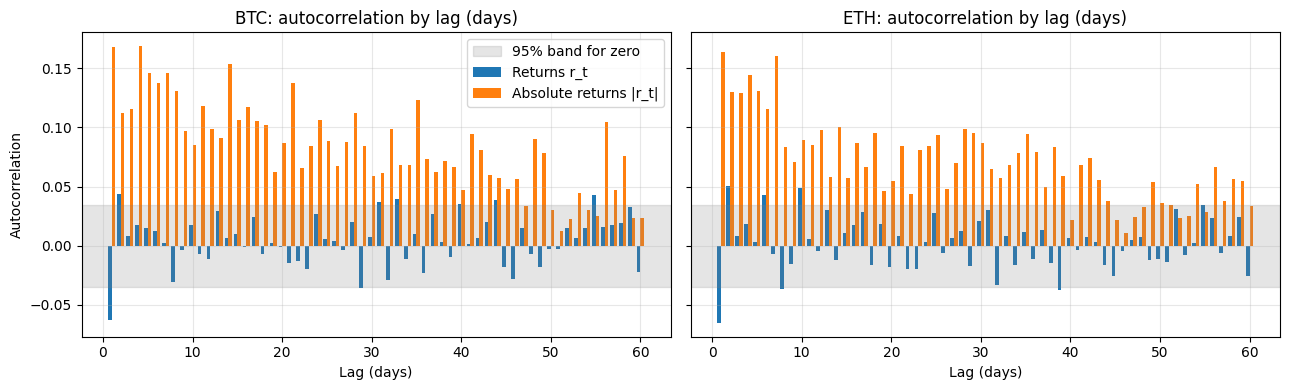

,Ann. volatility,Skewness,Excess kurtosis,Days beyond 4σ,Expected under normal
BTC,64%,-0.36,9.4,15,0.20
ETH,85%,-0.16,6.8,14,0.20


In [3]:
def acf(x, lags):
    x = np.asarray(x) - np.mean(x)
    return np.array([np.corrcoef(x[:-k], x[k:])[0, 1] for k in lags])


lags = np.arange(1, 61)
band = 1.96 / np.sqrt(len(returns))
fig, axes = plt.subplots(1, 2, figsize=(13, 4), sharey=True)
for ax, name in zip(axes, ["BTC", "ETH"]):
    ax.bar(lags - 0.2, acf(returns[name], lags), width=0.4, label="Returns r_t")
    ax.bar(lags + 0.2, acf(returns[name].abs(), lags), width=0.4, label="Absolute returns |r_t|")
    ax.axhspan(-band, band, color="gray", alpha=0.2, label="95% band for zero")
    ax.set_title(f"{name}: autocorrelation by lag (days)")
    ax.set_xlabel("Lag (days)")
axes[0].set_ylabel("Autocorrelation")
axes[0].legend()
plt.tight_layout()
plt.show()

facts = pd.DataFrame({n: {"Ann. volatility": returns[n].std() * np.sqrt(ANN),
                          "Skewness": stats.skew(returns[n]),
                          "Excess kurtosis": stats.kurtosis(returns[n]),
                          "Days beyond 4σ": int((np.abs(returns[n] - returns[n].mean()) > 4 * returns[n].std()).sum()),
                          "Expected under normal": 2 * stats.norm.sf(4) * len(returns)} for n in ["BTC", "ETH"]}).T
display(facts.style.format({"Ann. volatility": "{:.0%}", "Skewness": "{:.2f}", "Excess kurtosis": "{:.1f}",
                            "Days beyond 4σ": "{:.0f}", "Expected under normal": "{:.2f}"}))

Both facts are strong. The blue bars (returns) sit almost entirely inside the band for zero — apart from a small negative lag-1 value, past returns do not predict future returns. The orange bars (absolute returns) are positive at every lag and still clearly positive two months out: big days follow big days. And the tails are extreme — BTC had 15 days beyond 4 standard deviations and ETH 14, where a normal distribution would expect 0.2 in the whole sample.

## 3. GARCH(1,1) with Student-t errors

Let $\varepsilon_t = r_t - \mu$ be the demeaned return. GARCH(1,1) (Bollerslev, 1986) models its conditional variance as

$$ \sigma_t^2 = \omega + \alpha\,\varepsilon_{t-1}^2 + \beta\,\sigma_{t-1}^2, \qquad \varepsilon_t = \sigma_t z_t, \quad z_t \sim t_\nu \text{ (unit variance)}. $$

* $\alpha$ is how strongly today's variance reacts to yesterday's surprise;
* $\beta$ is how much of yesterday's variance carries over;
* $\alpha + \beta$ is the **persistence**: a shock to variance decays by that factor each day, so its **half-life** is $\ln 0.5 / \ln(\alpha + \beta)$ days;
* the **long-run variance** that forecasts revert to is $\omega / (1 - \alpha - \beta)$;
* $\nu$ is the Student-t degrees of freedom — the lower, the fatter the tails (Bollerslev, 1987).

The parameters are chosen to maximize the Student-t log-likelihood of the observed returns. The `arch` package does this in one line; writing it out keeps every step visible.

,omega,alpha,beta,nu,persistence α+β,half-life (days),long-run vol (ann.)
BTC,2.42e-05,0.103,0.869,5.1,0.972,25,57%
ETH,5.94e-05,0.102,0.862,5.1,0.964,19,77%


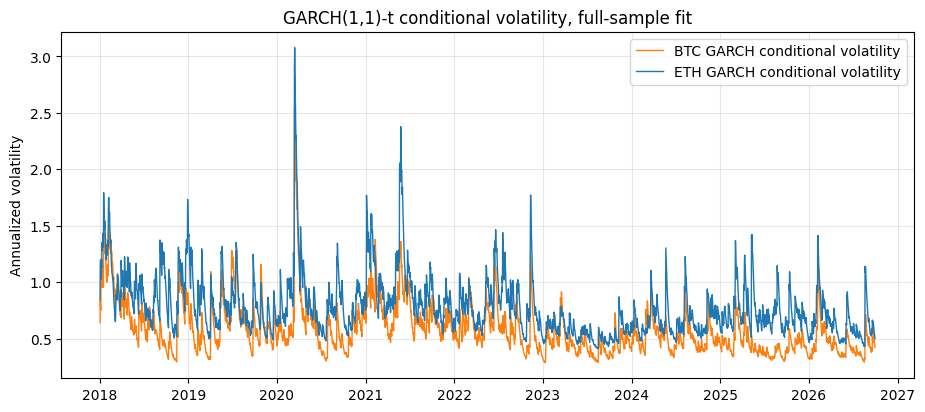

In [4]:
def garch_filter(params, eps, h0):
    # one-step-ahead conditional variances: h[t] is the forecast for day t made at the close of t-1
    omega, alpha, beta = params[:3]
    h = np.empty(len(eps) + 1)
    h[0] = h0
    for t in range(len(eps)):
        h[t + 1] = omega + alpha * eps[t]**2 + beta * h[t]
    return h


def neg_loglik(params, eps):
    omega, alpha, beta, nu = params
    if alpha + beta >= 0.9999:
        return 1e10
    h = garch_filter(params, eps, eps.var())[:-1]
    const = gammaln((nu + 1) / 2) - gammaln(nu / 2) - 0.5 * np.log(np.pi * (nu - 2))
    return -np.sum(const - 0.5 * np.log(h) - (nu + 1) / 2 * np.log1p(eps**2 / (h * (nu - 2))))


def fit_garch(r):
    mu = r.mean()
    eps = (r - mu).values
    v = eps.var()
    res = minimize(neg_loglik, [0.05 * v, 0.10, 0.85, 5.0], args=(eps,), method="L-BFGS-B",
                   bounds=[(1e-9, None), (1e-6, 0.5), (0.3, 0.9999), (2.1, 50.0)])
    return {"mu": mu, "omega": res.x[0], "alpha": res.x[1], "beta": res.x[2], "nu": res.x[3], "loglik": -res.fun}


fits = {n: fit_garch(returns[n]) for n in ["BTC", "ETH"]}
table = pd.DataFrame(fits).T
table["persistence α+β"] = table["alpha"] + table["beta"]
table["half-life (days)"] = np.log(0.5) / np.log(table["persistence α+β"])
table["long-run vol (ann.)"] = np.sqrt(table["omega"] / (1 - table["persistence α+β"]) * ANN)
display(table[["omega", "alpha", "beta", "nu", "persistence α+β", "half-life (days)", "long-run vol (ann.)"]]
        .style.format({"omega": "{:.2e}", "alpha": "{:.3f}", "beta": "{:.3f}", "nu": "{:.1f}",
                       "persistence α+β": "{:.3f}", "half-life (days)": "{:.0f}", "long-run vol (ann.)": "{:.0%}"}))

fig, ax = plt.subplots(figsize=(11, 4.5))
for n, color in [("BTC", "tab:orange"), ("ETH", "tab:blue")]:
    p = fits[n]
    eps = (returns[n] - p["mu"]).values
    h = garch_filter([p["omega"], p["alpha"], p["beta"]], eps, eps.var())[:-1]
    ax.plot(returns.index, np.sqrt(h * ANN), color=color, lw=1, label=f"{n} GARCH conditional volatility")
ax.set_ylabel("Annualized volatility")
ax.set_title("GARCH(1,1)-t conditional volatility, full-sample fit")
ax.legend()
plt.show()

The two coins have almost the same dynamics. A surprise raises next-day variance with weight $\alpha \approx 0.10$, and variance carries over with $\beta \approx 0.87$. Persistence of 0.96–0.97 means a volatility shock has a half-life of three to four weeks: a crash raises the forecast sharply, and the forecast then decays back towards the long-run level (57% for BTC, 77% for ETH) over the following months. $\nu \approx 5$ confirms the fat tails — a normal distribution corresponds to $\nu = \infty$.

The chart shows the model at work: spikes at the March 2020 COVID crash (ETH above 300% annualized), the May 2021 sell-off and the 2022 LUNA and FTX collapses, each followed by a gradual decay rather than an instant return to calm. Volatility in 2023–2026 has been structurally lower than in 2018–2021.

## 4. Out-of-sample forecast comparison

The full-sample fit above uses future data, so it cannot judge forecasts. Here every forecast for day $t$ uses only information up to the close of day $t-1$:

| Model | Variance forecast for day $t$ |
|---|---|
| **Constant** | sample variance of all returns before $t$ (expanding window) |
| **Rolling 30d** | sample variance of the previous 30 days |
| **EWMA** | RiskMetrics (1996): $\sigma_t^2 = \lambda\,\sigma_{t-1}^2 + (1-\lambda)\,\varepsilon_{t-1}^2$, $\lambda = 0.94$ — a GARCH with $\omega = 0$ and fixed weights |
| **GARCH-t** | parameters re-estimated at the start of each year on all data before it (expanding window), then run forward through the year |

The test period starts on 2020-01-01, so the first GARCH fit already has two years of data. The true variance is never observed, so each forecast $h_t$ is compared with the squared return $r_t^2$ — a noisy but unbiased proxy. Patton (2011) shows that only some loss functions rank forecasts correctly with such a proxy; we use the two standard ones:

$$ \text{MSE} = (r_t^2 - h_t)^2, \qquad \text{QLIKE} = \log h_t + \frac{r_t^2}{h_t}. $$

MSE is dominated by a few extreme days; QLIKE penalizes *under*-predicting variance much more than over-predicting it, which matches what a risk manager cares about.

In [5]:
OOS_START = "2020-01-01"


def forecasts(r):
    r = r.copy()
    out = pd.DataFrame(index=r.index)
    out["Constant"] = r.expanding().var().shift(1)
    out["Rolling 30d"] = r.rolling(30).var().shift(1)

    eps_all = (r - r.loc[:OOS_START].iloc[:-1].mean()).values
    ewma = np.empty(len(r))
    ewma[0] = eps_all[:30].var()
    for t in range(1, len(r)):
        ewma[t] = 0.94 * ewma[t - 1] + 0.06 * eps_all[t - 1]**2
    out["EWMA"] = ewma

    garch = pd.Series(np.nan, index=r.index)
    params_by_year = {}
    for year in range(pd.Timestamp(OOS_START).year, r.index[-1].year + 1):
        train = r.loc[:f"{year - 1}-12-31"]
        p = fit_garch(train)
        params_by_year[year] = p
        eps = (r.loc[:f"{year}-12-31"] - p["mu"]).values      # run the filter from the start, with this year's parameters
        h = garch_filter([p["omega"], p["alpha"], p["beta"]], eps, eps[:len(train)].var())[:-1]
        in_year = r.index.year == year
        garch[in_year] = h[np.flatnonzero(in_year)]
    out["GARCH-t"] = garch
    return out.loc[OOS_START:], params_by_year


fc, params_by_year, losses = {}, {}, {}
for n in ["BTC", "ETH"]:
    fc[n], params_by_year[n] = forecasts(returns[n])
    proxy = returns[n].loc[OOS_START:]**2
    mse = fc[n].apply(lambda h: ((proxy - h)**2).mean())
    qlike = fc[n].apply(lambda h: (np.log(h) + proxy / h).mean())
    losses[n] = pd.DataFrame({"MSE (vs Constant)": mse / mse["Constant"],
                              "QLIKE (vs Constant)": qlike - qlike["Constant"]})

display(pd.concat(losses, axis=1).style.format("{:.3f}")
        .highlight_min(axis=0, props="font-weight: bold"))
print("MSE is shown as a ratio to the Constant model (below 1 = better);")
print("QLIKE as a difference from it (below 0 = better). Bold = best model in each column.")

yearly_params = pd.DataFrame({y: {"alpha": p["alpha"], "beta": p["beta"], "nu": p["nu"]}
                              for y, p in params_by_year["BTC"].items()}).T
print("\nBTC GARCH parameters, re-estimated each January on all earlier data:")
print(yearly_params.round(3).to_string())

MSE is shown as a ratio to the Constant model (below 1 = better);
QLIKE as a difference from it (below 0 = better). Bold = best model in each column.

BTC GARCH parameters, re-estimated each January on all earlier data:
      alpha   beta     nu
2020  0.105  0.877  5.144
2021  0.103  0.867  5.092
2022  0.105  0.878  5.149
2023  0.061  0.921  5.159
2024  0.104  0.874  5.125
2025  0.056  0.926  5.157
2026  0.063  0.936  3.291


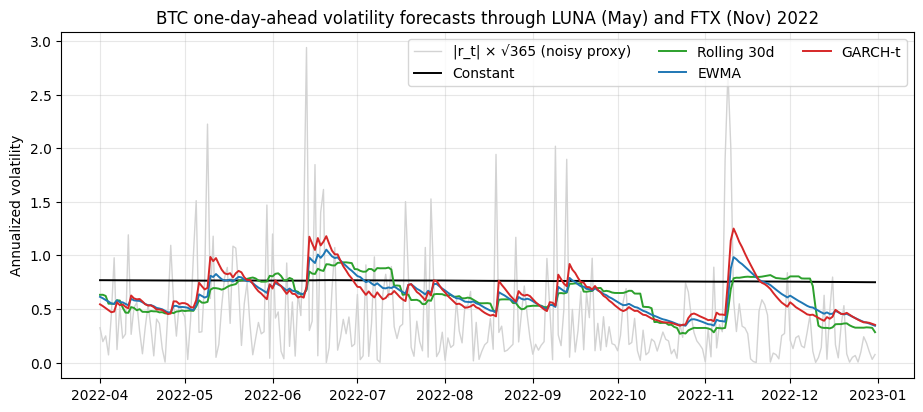

In [6]:
fig, ax = plt.subplots(figsize=(11, 4.5))
window = slice("2022-04-01", "2022-12-31")
ax.plot(returns["BTC"].loc[window].abs() * np.sqrt(ANN), color="lightgray", lw=1, label="|r_t| × √365 (noisy proxy)")
for col, color in [("Constant", "k"), ("Rolling 30d", "tab:green"), ("EWMA", "tab:blue"), ("GARCH-t", "tab:red")]:
    ax.plot(np.sqrt(fc["BTC"][col].loc[window] * ANN), color=color, lw=1.4, label=col)
ax.set_ylabel("Annualized volatility")
ax.set_title("BTC one-day-ahead volatility forecasts through LUNA (May) and FTX (Nov) 2022")
ax.legend(ncol=3)
plt.show()

Every model that adapts beats the constant forecast, and the two exponential models — EWMA and GARCH-t — clearly beat the 30-day rolling window. Under QLIKE, the loss that matters most for risk management, GARCH-t is the best model for both coins, ahead of EWMA. Under MSE the differences are tiny (1–3%) because MSE is dominated by a handful of extreme days that no model foresaw, and EWMA edges out GARCH.

The chart of 2022 shows why. The rolling window reacts to a shock with a lag, then holds the high estimate for exactly 30 days and drops off a cliff when the shock leaves the window (early December). EWMA and GARCH jump the day after a big move and decay smoothly. GARCH reacts slightly more strongly and decays towards a long-run level instead of towards zero, which is what makes it better under QLIKE. The re-estimated parameters are stable from year to year, so the model is not being refitted to noise — though in 2023, 2025 and 2026 the fit shifted towards smaller $\alpha$ and larger $\beta$ (slower, smoother volatility).

The practical gap between EWMA and GARCH is small. EWMA needs no estimation at all, which is why RiskMetrics adopted it.

## 5. Volatility targeting

Each day the strategy holds a weight $w_t$ in the coin and $1 - w_t$ in cash, chosen so that the *forecast* volatility of the position equals a target:

$$ w_t = \min\!\left(\frac{\sigma_{\text{target}}}{\hat\sigma_t},\; w_{\max}\right), $$

where $\hat\sigma_t$ is the annualized forecast for day $t$ made at the close of day $t-1$, $\sigma_{\text{target}} = 50\%$ and $w_{\max} = 1$ (no leverage). Cash earns zero, every change in weight pays 10 bp, and the Sharpe ratio is mean return / volatility.

Comparing a volatility-targeted strategy with buy-and-hold is not a fair fight: the strategy is usually *less* invested, so it should have lower return and lower risk regardless of timing. The fair benchmark, used by Moreira & Muir (2017) and Cederburg et al. (2020), is a **static** portfolio that holds the coin at a *constant* weight equal to the strategy's average weight. Any difference between the two comes from *when* the strategy took risk, not *how much*.

In [7]:
def run_strategy(r, w):
    w = w.clip(0, 1)
    turnover = w.diff().abs().fillna(w.iloc[0])
    return w * r - COST * turnover, turnover


def metrics(daily, w=None, turnover=None):
    wealth = (1 + daily).cumprod()
    out = {"Ann. return": daily.mean() * ANN,
           "CAGR": wealth.iloc[-1] ** (ANN / len(daily)) - 1,
           "Ann. vol": daily.std() * np.sqrt(ANN),
           "Sharpe": daily.mean() / daily.std() * np.sqrt(ANN),
           "Max drawdown": (wealth / wealth.cummax() - 1).min(),
           "Worst day": daily.min(),
           "Excess kurtosis": stats.kurtosis(daily),
           "Vol of 90d vol": (daily.rolling(90).std() * np.sqrt(ANN)).std()}
    out["Avg weight"] = w.mean() if w is not None else 1.0
    out["Turnover / yr"] = turnover.mean() * ANN if turnover is not None else 0.0
    return out


results, curves, weights = {}, {}, {}
for n in ["BTC", "ETH"]:
    r = returns[n].loc[OOS_START:]
    rows = {"Buy & hold": metrics(r)}
    curves[n] = {"Buy & hold": (1 + r).cumprod()}
    for model in ["Rolling 30d", "EWMA", "GARCH-t"]:
        w = (TARGET / np.sqrt(fc[n][model] * ANN)).clip(upper=1.0)
        daily, turnover = run_strategy(r, w)
        rows[f"VT {model}"] = metrics(daily, w, turnover)
        curves[n][f"VT {model}"] = (1 + daily).cumprod()
        weights[(n, model)] = w
    w_static = pd.Series(weights[(n, "GARCH-t")].mean(), index=r.index)
    daily, turnover = run_strategy(r, w_static)
    rows["Static (same avg weight as VT GARCH)"] = metrics(daily, w_static, turnover)
    curves[n]["Static"] = (1 + daily).cumprod()
    results[n] = pd.DataFrame(rows).T

pct = ["Ann. return", "CAGR", "Ann. vol", "Max drawdown", "Worst day", "Vol of 90d vol", "Avg weight"]
for n in ["BTC", "ETH"]:
    print(f"\n{n}, {OOS_START} → {returns.index[-1].date()}")
    display(results[n].style.format({c: "{:.1%}" for c in pct} |
                                    {"Sharpe": "{:.2f}", "Excess kurtosis": "{:.1f}", "Turnover / yr": "{:.1f}"}))


BTC, 2020-01-01 → 2026-09-30


,Ann. return,CAGR,Ann. vol,Sharpe,Max drawdown,Worst day,Excess kurtosis,Vol of 90d vol,Avg weight,Turnover / yr
Buy & hold,54.8%,43.8%,60.2%,0.91,-76.6%,-39.5%,13.2,18.8%,100.0%,0.0
VT Rolling 30d,40.6%,32.8%,48.9%,0.83,-71.8%,-32.9%,14.0,9.3%,86.8%,3.9
VT EWMA,39.8%,32.3%,48.2%,0.83,-70.5%,-32.1%,13.3,8.8%,86.7%,5.3
VT GARCH-t,41.9%,34.8%,48.7%,0.86,-69.4%,-30.5%,10.9,9.2%,87.4%,8.7
Static (same avg weight as VT GARCH),47.9%,40.2%,52.6%,0.91,-71.2%,-34.5%,13.2,16.4%,87.4%,0.1



ETH, 2020-01-01 → 2026-09-30


,Ann. return,CAGR,Ann. vol,Sharpe,Max drawdown,Worst day,Excess kurtosis,Vol of 90d vol,Avg weight,Turnover / yr
Buy & hold,78.1%,56.7%,80.8%,0.97,-79.3%,-44.6%,9.3,25.0%,100.0%,0.0
VT Rolling 30d,52.5%,47.2%,52.7%,1.00,-65.7%,-20.0%,5.0,6.4%,72.4%,5.2
VT EWMA,50.9%,45.6%,51.8%,0.98,-64.2%,-21.3%,5.4,6.1%,71.7%,7.2
VT GARCH-t,48.3%,44.2%,48.4%,1.00,-56.5%,-18.0%,6.5,8.8%,65.3%,11.0
Static (same avg weight as VT GARCH),51.0%,44.7%,52.8%,0.97,-62.4%,-29.1%,9.3,16.3%,65.3%,0.1


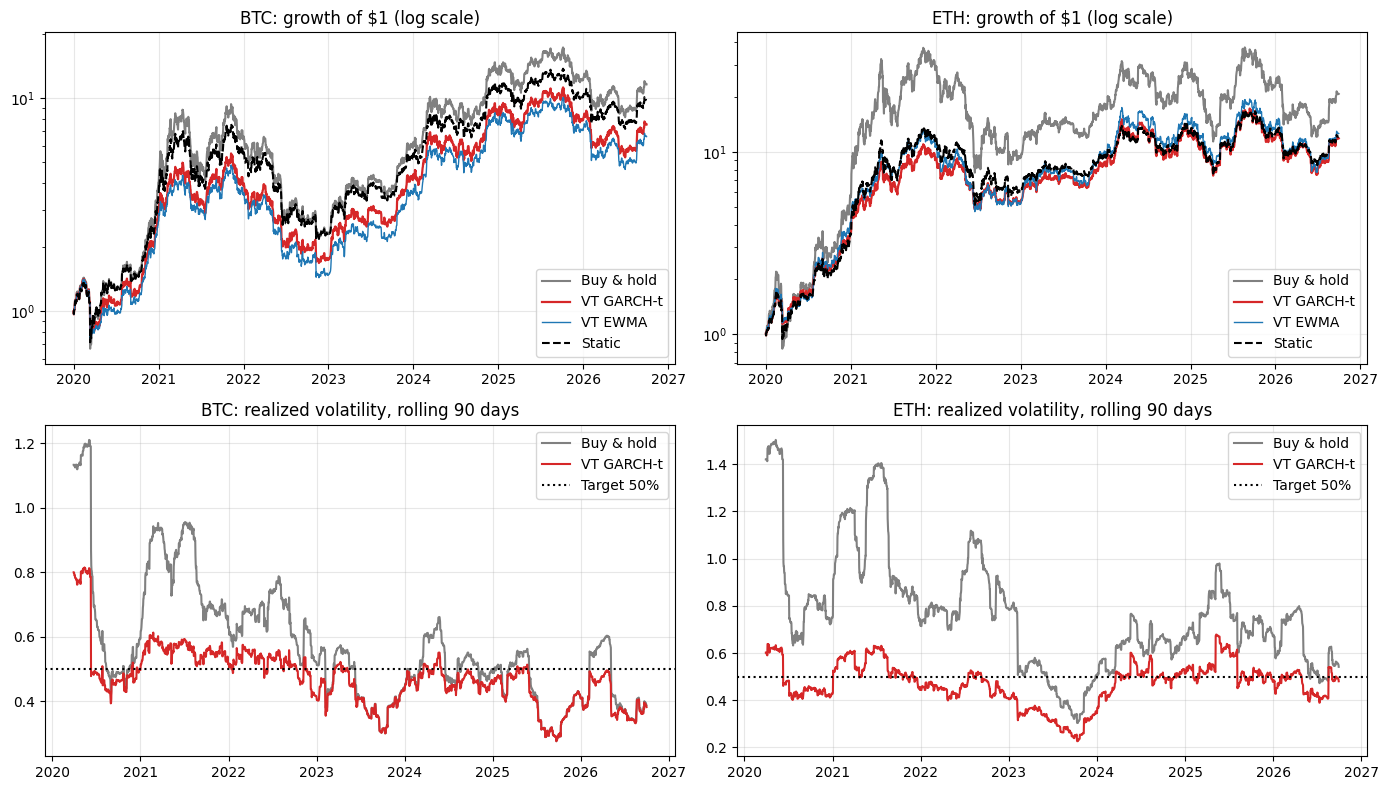

In [8]:
fig, axes = plt.subplots(2, 2, figsize=(14, 8))
for col, n in enumerate(["BTC", "ETH"]):
    ax = axes[0, col]
    for label, style in [("Buy & hold", dict(color="gray")), ("VT GARCH-t", dict(color="tab:red", lw=1.6)),
                         ("VT EWMA", dict(color="tab:blue", lw=1)), ("Static", dict(color="k", ls="--"))]:
        ax.plot(curves[n][label], label=label, **style)
    ax.set_yscale("log")
    ax.set_title(f"{n}: growth of $1 (log scale)")
    ax.legend()

    ax = axes[1, col]
    r = returns[n].loc[OOS_START:]
    w = weights[(n, "GARCH-t")]
    ax.plot(r.rolling(90).std() * np.sqrt(ANN), color="gray", label="Buy & hold")
    ax.plot((w * r).rolling(90).std() * np.sqrt(ANN), color="tab:red", label="VT GARCH-t")
    ax.axhline(TARGET, color="k", ls=":", label=f"Target {TARGET:.0%}")
    ax.set_title(f"{n}: realized volatility, rolling 90 days")
    ax.legend()
plt.tight_layout()
plt.show()

Volatility targeting does exactly what it promises to the *risk* profile, and not much for the *return* profile:

* **Risk is stabilized.** The bottom charts show realized volatility held at or just below the 50% target (below it in calm markets, when the 100% cap stops the strategy from adding exposure), while buy-and-hold swung between about 30% and 150%. The "vol of 90-day vol" falls by half or more (BTC 18.8% → 9.2%, ETH 25.0% → 8.8%).
* **Tails are thinner.** ETH's worst day improves from −29% for the matched static portfolio to −18%, its maximum drawdown from −62% to −57%, and its excess kurtosis from 9.3 to 6.5. BTC improves too, by less.
* **Sharpe ratios do not improve for BTC.** Against the fair benchmark — the static portfolio with the same average weight — BTC's Sharpe is *lower* (0.86 vs 0.91) and ETH's only slightly higher (1.00 vs 0.97). Against buy-and-hold the strategy loses a lot of return, but almost all of that is from holding less on average (87% for BTC, 65% for ETH), not from bad timing.
* **One crash it could not dodge.** BTC's worst day, −39.5% on 12 March 2020, came after a calm February, so every model had forecast low volatility and the strategy was fully invested. Volatility targeting cuts exposure *after* volatility rises; it cannot see a crash coming out of a quiet market.

### Robustness: other targets, and allowing leverage

One target is one data point. With a 50% target and no leverage, the BTC strategy spends most days at the 100% cap (BTC's volatility is often below 50%), so it can only ever *cut* risk. The grid below repeats the GARCH-t strategy for targets from 30% to 60%, with the weight capped at 1× (no leverage) or 2× (borrowing allowed, at zero cost here — generous to the strategy). Each cell compares it with its own static benchmark at the same average weight: positive Sharpe and drawdown differences favour volatility targeting.

In [9]:
def run_strategy_capped(r, w, cap):
    w = w.clip(0, cap)
    turnover = w.diff().abs().fillna(w.iloc[0])
    return w * r - COST * turnover, w


rows = []
for n in ["BTC", "ETH"]:
    r = returns[n].loc[OOS_START:]
    sigma_hat = np.sqrt(fc[n]["GARCH-t"] * ANN)
    for cap in [1.0, 2.0]:
        for target in [0.30, 0.40, 0.50, 0.60]:
            daily, w = run_strategy_capped(r, target / sigma_hat, cap)
            static, _ = run_strategy_capped(r, pd.Series(w.mean(), index=r.index), cap)
            vt, st = metrics(daily), metrics(static)
            rows.append({"Coin": n, "Max weight": f"{cap:.0f}x", "Target": target, "Avg weight": w.mean(),
                         "Days at cap": (w >= cap - 1e-9).mean(),
                         "Sharpe VT": vt["Sharpe"], "Sharpe static": st["Sharpe"],
                         "Δ Sharpe": vt["Sharpe"] - st["Sharpe"],
                         "Δ Max DD": vt["Max drawdown"] - st["Max drawdown"],
                         "Δ Worst day": vt["Worst day"] - st["Worst day"]})
grid = pd.DataFrame(rows).set_index(["Coin", "Max weight", "Target"])
display(grid.style.format({"Avg weight": "{:.0%}", "Days at cap": "{:.0%}", "Sharpe VT": "{:.2f}",
                           "Sharpe static": "{:.2f}", "Δ Sharpe": "{:+.2f}", "Δ Max DD": "{:+.1%}",
                           "Δ Worst day": "{:+.1%}"}, na_rep="")
        .format_index("{:.0%}", level=2)
        .background_gradient(subset=["Δ Sharpe"], cmap="RdYlGn", vmin=-0.2, vmax=0.2))

The pattern holds across every setting. For BTC, volatility targeting has a Sharpe ratio 0.03–0.05 *below* its static twin in all eight cases. For ETH it is 0.02–0.03 above in all eight. Meanwhile the maximum drawdown and worst day improve in every one of the 16 cases, by between 0.3 and 13 percentage points.

With 2× leverage allowed, the cap never binds, so the GARCH weights are just $c / \hat\sigma_t$ for different constants $c$; changing the target only scales both the strategy and its benchmark, which is why the Sharpe difference is identical across targets. With a 1× cap, high targets push BTC to the cap on up to two-thirds of days, which turns the strategy into "buy-and-hold except when volatile".

This is the mixed result of the literature in miniature. Harvey et al. (2018) found volatility targeting reliably trims the left tail, which it does here. Moreira & Muir (2017) found Sharpe gains, but Cederburg et al. (2020) showed that out-of-sample these gains are not systematic — here a small loss for BTC and a small gain for ETH, neither large enough to rely on over a seven-year sample.

## 6. Takeaways

1. **Crypto volatility is highly forecastable; crypto returns are not.** Absolute returns are autocorrelated for months, and GARCH(1,1)-t fits BTC and ETH with persistence near 0.97, a three-to-four-week half-life and Student-t tails with about 5 degrees of freedom.
2. **Any adaptive forecast beats a constant, and exponential weighting beats a rolling window.** GARCH-t had the lowest out-of-sample QLIKE loss for both coins; EWMA with λ = 0.94 was close behind with nothing to estimate. The 30-day window lags shocks and then drops them abruptly.
3. **Volatility targeting reliably stabilizes risk and trims the tails.** Realized volatility stayed at or below the 50% target, and the worst day and maximum drawdown improved against a matched static portfolio in every setting tested.
4. **It does not reliably raise the Sharpe ratio.** Against the fair, same-average-weight benchmark, BTC lost 0.03–0.05 and ETH gained 0.02–0.03 across all targets and leverage caps. Most of the gap to buy-and-hold is lower average exposure, not timing.
5. **It cannot anticipate a crash from a calm market.** The largest loss, March 2020, hit at full exposure. Targeting reacts to volatility; it does not predict it from nothing.

**Next steps:** asymmetric GARCH (GJR or EGARCH) to let negative returns raise volatility more than positive ones; intraday range-based volatility (Parkinson, Garman–Klass) as a less noisy proxy and predictor; and applying the same targeting to the equal-weight and minimum-variance crypto portfolios from the Mean-Variance notebook.

## References

* Engle, R. F. (1982). Autoregressive Conditional Heteroscedasticity with Estimates of the Variance of United Kingdom Inflation. *Econometrica* 50(4), 987–1007.
* Bollerslev, T. (1986). Generalized Autoregressive Conditional Heteroskedasticity. *Journal of Econometrics* 31(3), 307–327.
* Bollerslev, T. (1987). A Conditionally Heteroskedastic Time Series Model for Speculative Prices and Rates of Return. *Review of Economics and Statistics* 69(3), 542–547.
* Cont, R. (2001). Empirical Properties of Asset Returns: Stylized Facts and Statistical Issues. *Quantitative Finance* 1(2), 223–236.
* J.P. Morgan / Reuters (1996). *RiskMetrics — Technical Document*, 4th ed.
* Patton, A. J. (2011). Volatility Forecast Comparison Using Imperfect Volatility Proxies. *Journal of Econometrics* 160(1), 246–256.
* Moreira, A., Muir, T. (2017). Volatility-Managed Portfolios. *Journal of Finance* 72(4), 1611–1644.
* Harvey, C. R., Hoyle, E., Korgaonkar, R., Rattray, S., Sargaison, M., Van Hemert, O. (2018). The Impact of Volatility Targeting. *Journal of Portfolio Management* 45(1), 14–33.
* Cederburg, S., O'Doherty, M. S., Wang, F., Yan, X. (2020). On the Performance of Volatility-Managed Portfolios. *Journal of Financial Economics* 138(1), 95–117.